# D2C Customer Churn Capstone

# Part 1: Data Audit, EDA & Business Understanding

## Objective

This notebook analyzes customer behavior, transaction patterns, support interactions, and digital engagement data to identify churn-risk patterns and business retention opportunities.

The analysis includes:

- data quality validation,
- leakage prevention,
- exploratory data analysis,
- churn behavior investigation,
- support and engagement analysis,
- and business-focused churn insights.

---

## Datasets Used

- customers.csv
- orders.csv
- support_tickets.csv
- web_events_snapshot.csv
- churn_labels.csv
- intervention_history.csv

---

# **Author:** Prateek Parmar
# **Student ID:** AIML_IITP_2506247

# 0. Setup & Data Load

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
from pathlib import Path
import pandas as pd

# Create output folder

OUT = Path("artifacts")

OUT.mkdir(exist_ok=True)

# Sample rows dataframe

sample_rows = pd.DataFrame([

    {
        "customer_id": "C100231",
        "recency_days": 12,
        "frequency_90d": 4,
        "monetary_90d": 2480.0,
        "avg_rating": 4.6,
        "ticket_count_90d": 0,
        "churned": 0
    },

    {
        "customer_id": "C100847",
        "recency_days": 78,
        "frequency_90d": 1,
        "monetary_90d": 399.0,
        "avg_rating": 3.1,
        "ticket_count_90d": 2,
        "churned": 1
    },

    {
        "customer_id": "C101502",
        "recency_days": 34,
        "frequency_90d": 2,
        "monetary_90d": 890.0,
        "avg_rating": 4.2,
        "ticket_count_90d": 1,
        "churned": 0
    },

    {
        "customer_id": "C102119",
        "recency_days": 120,
        "frequency_90d": 0,
        "monetary_90d": 0.0,
        "avg_rating": 2.8,
        "ticket_count_90d": 3,
        "churned": 1
    },

    {
        "customer_id": "C102788",
        "recency_days": 5,
        "frequency_90d": 6,
        "monetary_90d": 4120.0,
        "avg_rating": 4.9,
        "ticket_count_90d": 0,
        "churned": 0
    }

])

# Export CSV

sample_rows.to_csv(

    OUT / "part1_sample_rows.csv",

    index=False

)

print("CSV exported successfully")

sample_rows

CSV exported successfully


,customer_id,recency_days,frequency_90d,monetary_90d,avg_rating,ticket_count_90d,churned
0,C100231,12,4,2480.0,4.6,0,0
1,C100847,78,1,399.0,3.1,2,1
2,C101502,34,2,890.0,4.2,1,0
3,C102119,120,0,0.0,2.8,3,1
4,C102788,5,6,4120.0,4.9,0,0


In [4]:
# Dataset path

data_path = "../d2c churn data package/"

In [5]:
# Load datasets

customers = pd.read_csv(data_path + "customers.csv")
orders = pd.read_csv(data_path + "orders.csv")
support_tickets = pd.read_csv(data_path + "support_tickets.csv")
web_events = pd.read_csv(data_path + "web_events_snapshot.csv")
churn_labels = pd.read_csv(data_path + "churn_labels.csv")
intervention_history = pd.read_csv(data_path + "intervention_history.csv")

print("Datasets loaded successfully")

Datasets loaded successfully


# 1. Dataset Inspection

In [6]:
# Check dataset shapes

print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Support Tickets:", support_tickets.shape)
print("Web Events:", web_events.shape)
print("Churn Labels:", churn_labels.shape)
print("Intervention History:", intervention_history.shape)

Customers: (2400, 9)
Orders: (10009, 10)
Support Tickets: (1921, 8)
Web Events: (2400, 10)
Churn Labels: (2400, 4)
Intervention History: (2400, 5)


In [7]:
# Preview datasets

display(customers.head())
display(orders.head())
display(support_tickets.head())
display(web_events.head())
display(churn_labels.head())
display(intervention_history.head())

,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes
3,CUST00004,2025-04-15,Tier 3,25-34,Google Search,NaN,Fragrance,Normal,No
4,CUST00005,2024-08-21,Tier 3,35-44,Organic,Gold,Hair Care,Combination,Yes


,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
0,ORD000001,CUST00001,2024-08-06,Skin Care,1,540.70,0.43,3,0,4.0
1,ORD000002,CUST00001,2024-10-23,Hair Care,2,467.96,0.64,4,1,1.0
2,ORD000006,CUST00001,2025-01-18,Makeup,1,581.81,0.27,7,0,4.0
3,ORD000005,CUST00001,2025-01-22,Hair Care,1,433.15,0.27,2,0,4.0
4,ORD000004,CUST00001,2025-02-28,Skin Care,1,569.22,0.34,4,0,4.0


,ticket_id,customer_id,ticket_date,issue_type,support_channel,resolution_hours,sentiment_score,reopened
0,TKT000001,CUST00001,2024-10-28,damaged_item,chat,3.9,-0.16,0
1,TKT000002,CUST00001,2025-02-03,payment_issue,chat,4.8,0.44,0
2,TKT000003,CUST00002,2025-08-30,late_delivery,chat,1.0,0.00,0
3,TKT000004,CUST00005,2025-05-02,late_delivery,call,37.7,-1.00,0
4,TKT000005,CUST00006,2025-08-13,general_query,call,23.1,-0.68,1


,customer_id,snapshot_date,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago
0,CUST00001,2025-09-30,1,4,0,0,0,2,0,20
1,CUST00002,2025-09-30,8,31,4,2,3,0,0,0
2,CUST00003,2025-09-30,1,3,0,0,0,0,0,26
3,CUST00004,2025-09-30,1,6,0,0,0,0,0,14
4,CUST00005,2025-09-30,18,95,4,1,1,3,1,9


,customer_id,snapshot_date,churn_next_60d,split
0,CUST00001,2025-09-30,1,train
1,CUST00002,2025-09-30,0,train
2,CUST00003,2025-09-30,1,train
3,CUST00004,2025-09-30,1,train
4,CUST00005,2025-09-30,0,train


,customer_id,snapshot_date,last_campaign_received,last_campaign_cost,manual_priority_bucket
0,CUST00001,2025-09-30,welcome_offer,25,high
1,CUST00002,2025-09-30,free_shipping,12,medium
2,CUST00003,2025-09-30,none,18,high
3,CUST00004,2025-09-30,free_shipping,40,high
4,CUST00005,2025-09-30,welcome_offer,18,medium


In [8]:
# Dataset information

customers.info()
orders.info()
support_tickets.info()
web_events.info()
churn_labels.info()
intervention_history.info()

<class 'pandas.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   customer_id          2400 non-null   str  
 1   signup_date          2400 non-null   str  
 2   city_tier            2400 non-null   str  
 3   age_group            2400 non-null   str  
 4   acquisition_channel  2400 non-null   str  
 5   loyalty_tier         1014 non-null   str  
 6   preferred_category   2400 non-null   str  
 7   skin_type            1999 non-null   str  
 8   marketing_consent    2400 non-null   str  
dtypes: str(9)
memory usage: 168.9 KB
<class 'pandas.DataFrame'>
RangeIndex: 10009 entries, 0 to 10008
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       10009 non-null  str    
 1   customer_id    10009 non-null  str    
 2   order_date     10009 non-null  str    
 3   category       1

# 2. Data-Quality Report
Covers: missing values, duplicates, dtypes, date consistency, join-key integrity, snapshot/leakage prevention, duplicate-like orders, outliers, post-snapshot & treatment leakage.

- 2.1 Missing Value Analysis

# Missing Value Analysis

In [9]:
# Missing values check

missing_values = pd.DataFrame({
    "Missing Values": customers.isnull().sum(),
    "Percentage": (customers.isnull().sum() / len(customers)) * 100
})

missing_values.sort_values(by="Missing Values", ascending=False)

,Missing Values,Percentage
loyalty_tier,1386,57.750000
skin_type,401,16.708333
customer_id,0,0.000000
signup_date,0,0.000000
city_tier,0,0.000000
acquisition_channel,0,0.000000
age_group,0,0.000000
preferred_category,0,0.000000
marketing_consent,0,0.000000


In [10]:
# Missing values for all datasets

datasets = {
    "customers": customers,
    "orders": orders,
    "support_tickets": support_tickets,
    "web_events": web_events,
    "churn_labels": churn_labels,
    "intervention_history": intervention_history
}

for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print(df.isnull().sum())


CUSTOMERS
customer_id               0
signup_date               0
city_tier                 0
age_group                 0
acquisition_channel       0
loyalty_tier           1386
preferred_category        0
skin_type               401
marketing_consent         0
dtype: int64

ORDERS
order_id          0
customer_id       0
order_date        0
category          0
quantity          0
gross_amount      0
discount_pct      0
delivery_days     0
returned          0
rating           80
dtype: int64

SUPPORT_TICKETS
ticket_id           0
customer_id         0
ticket_date         0
issue_type          0
support_channel     0
resolution_hours    0
sentiment_score     0
reopened            0
dtype: int64

WEB_EVENTS
customer_id            0
snapshot_date          0
sessions_30d           0
product_views_30d      0
cart_adds_30d          0
wishlist_adds_30d      0
abandoned_carts_30d    0
email_opens_30d        0
campaign_clicks_30d    0
last_visit_days_ago    0
dtype: int64

CHURN_LABELS
customer

- 2.2 Duplicate Record Analysis

# Duplicate Record Analysis

In [11]:
# Checking duplicate rows in all datasets

for name, df in datasets.items():
    duplicates = df.duplicated().sum()
    print(f"{name}: {duplicates} duplicate rows")

customers: 0 duplicate rows
orders: 0 duplicate rows
support_tickets: 0 duplicate rows
web_events: 0 duplicate rows
churn_labels: 0 duplicate rows
intervention_history: 0 duplicate rows


- 2.3 Data Types & Date Consistency

# Data Type Validation

In [12]:
# Convert date columns to datetime

customers['signup_date'] = pd.to_datetime(customers['signup_date'])
orders['order_date'] = pd.to_datetime(orders['order_date'])
churn_labels['snapshot_date'] = pd.to_datetime(churn_labels['snapshot_date'])

print("Date conversion completed")

print("\nCustomers Data Types:")
print(customers.dtypes)

print("\nOrders Data Types:")
print(orders.dtypes)

Date conversion completed

Customers Data Types:
customer_id                       str
signup_date            datetime64[us]
city_tier                         str
age_group                         str
acquisition_channel               str
loyalty_tier                      str
preferred_category                str
skin_type                         str
marketing_consent                 str
dtype: object

Orders Data Types:
order_id                    str
customer_id                 str
order_date       datetime64[us]
category                    str
quantity                  int64
gross_amount            float64
discount_pct            float64
delivery_days             int64
returned                  int64
rating                  float64
dtype: object


- 2.4 Join-Key Integrity (customer_id across files)

In [13]:
# Join key integrity checks

customer_keys = set(customers['customer_id'])

orders_missing_customers = orders[
    ~orders['customer_id'].isin(customer_keys)
]

support_missing_customers = support_tickets[
    ~support_tickets['customer_id'].isin(customer_keys)
]

web_missing_customers = web_events[
    ~web_events['customer_id'].isin(customer_keys)
]

print("Orders with missing customer keys:",
      orders_missing_customers.shape[0])

print("Support tickets with missing customer keys:",
      support_missing_customers.shape[0])

print("Web events with missing customer keys:",
      web_missing_customers.shape[0])

Orders with missing customer keys: 0
Support tickets with missing customer keys: 0
Web events with missing customer keys: 0


In [74]:
# Duplicate customer_id checks

print("Duplicate customer IDs in customers:",
      customers['customer_id'].duplicated().sum())

print("Duplicate churn label IDs:",
      churn_labels['customer_id'].duplicated().sum())

Duplicate customer IDs in customers: 0
Duplicate churn label IDs: 0


- 2.5 Snapshot Integrity & Leakage Prevention

SNAPSHOT_DATE freezes the feature window so post-snapshot rows can never leak into training.

# Snapshot Integrity & Leakage Prevention

In [14]:
SNAPSHOT_DATE = "2025-09-30"

post_snapshot_orders = orders[
    orders["order_date"] > SNAPSHOT_DATE
]

print("Post-snapshot order rows:", post_snapshot_orders.shape[0])

post_snapshot_orders.head()

Post-snapshot order rows: 1872


,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
7,ORD008129,CUST00002,2025-10-24,Skin Care,1,562.21,0.16,1,0,5.0
8,ORD008130,CUST00002,2025-10-26,Skin Care,1,569.89,0.18,4,0,4.0
15,ORD008132,CUST00005,2025-10-29,Hair Care,1,379.14,0.34,4,0,2.0
16,ORD008131,CUST00005,2025-11-19,Baby Care,3,980.38,0.22,4,0,4.0
22,ORD008133,CUST00006,2025-10-06,Baby Care,1,217.30,0.38,4,0,4.0


In [15]:
orders_pre_snapshot = orders[
    orders["order_date"] <= SNAPSHOT_DATE
]

print("Original orders shape:", orders.shape)
print("Filtered pre-snapshot orders shape:", orders_pre_snapshot.shape)

Original orders shape: (10009, 10)
Filtered pre-snapshot orders shape: (8137, 10)


- 2.6 Duplicate-Like Orders (_DUP suffix)

# Duplicate-Like Order Investigation

In [16]:
dup_orders = orders[
    orders["order_id"].str.contains("_DUP", na=False)
]

print("Duplicate-like order rows:", dup_orders.shape[0])

dup_orders.head()

Duplicate-like order rows: 12


,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
601,ORD008249_DUP,CUST00153,2025-11-04,Hair Care,1,321.31,0.36,8,0,3.0
2621,ORD002124_DUP,CUST00628,2025-03-18,Skin Care,1,410.04,0.47,3,0,5.0
3534,ORD002862_DUP,CUST00837,2025-07-12,Hair Care,3,952.02,0.47,4,0,4.0
3602,ORD002916_DUP,CUST00848,2025-09-26,Skin Care,1,547.18,0.28,2,0,5.0
3675,ORD002970_DUP,CUST00869,2024-12-22,Fragrance,1,818.64,0.18,2,0,4.0


In [17]:
dup_orders[[
    "order_id",
    "customer_id",
    "gross_amount",
    "order_date"
]].sample(10)

,order_id,customer_id,gross_amount,order_date
4799,ORD003897_DUP,CUST01140,769.96,2025-04-14
5633,ORD004577_DUP,CUST01335,533.07,2025-02-12
601,ORD008249_DUP,CUST00153,321.31,2025-11-04
3602,ORD002916_DUP,CUST00848,547.18,2025-09-26
2621,ORD002124_DUP,CUST00628,410.04,2025-03-18
6780,ORD005529_DUP,CUST01621,339.33,2024-08-12
7628,ORD009518_DUP,CUST01820,802.18,2025-10-16
3675,ORD002970_DUP,CUST00869,818.64,2024-12-22
3534,ORD002862_DUP,CUST00837,952.02,2025-07-12
6687,ORD005451_DUP,CUST01601,1160.41,2024-11-07


In [18]:
print("Revenue impact of duplicate-like rows:")

dup_orders["gross_amount"].sum()

Revenue impact of duplicate-like rows:


np.float64(7928.05)

- 2.7 Gross-Amount Outliers

# Gross Amount Outlier Analysis

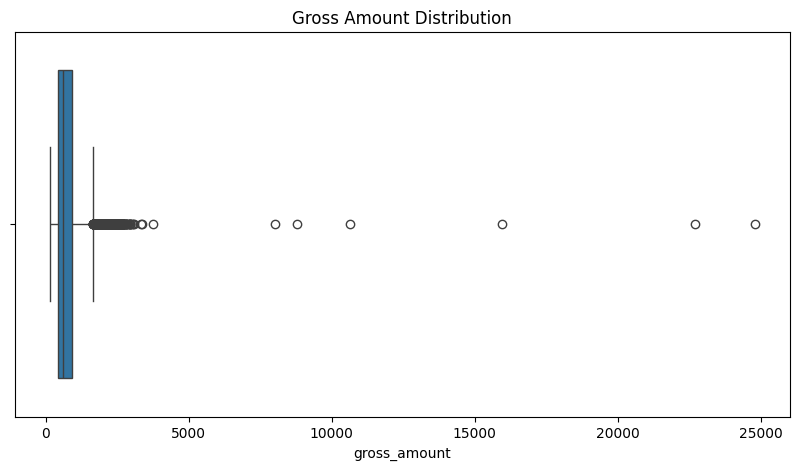

In [19]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=orders_pre_snapshot["gross_amount"]
)

plt.title("Gross Amount Distribution")

plt.show()

In [20]:
orders_pre_snapshot["gross_amount"].describe(
    percentiles=[0.90,0.95,0.99]
)

count     8137.000000
mean       752.018404
std        626.176406
min        149.000000
90%       1371.424000
95%       1685.906000
99%       2342.974400
max      24789.380000
Name: gross_amount, dtype: float64

In [21]:
high_value_orders = orders_pre_snapshot[
    orders_pre_snapshot["gross_amount"] >
    orders_pre_snapshot["gross_amount"].quantile(0.99)
]

high_value_orders.head()

,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
73,ORD000055,CUST00020,2024-09-27,Skin Care,4,2710.51,0.06,3,0,5.0
248,ORD000188,CUST00066,2024-11-14,Makeup,4,2447.60,0.24,3,0,3.0
341,ORD000274,CUST00091,2024-12-06,Skin Care,4,2402.71,0.10,4,0,4.0
560,ORD000454,CUST00146,2024-09-28,Fragrance,3,2447.42,0.16,3,0,4.0
616,ORD000493,CUST00156,2025-07-18,Skin Care,4,2467.83,0.12,3,0,2.0


- 2.8 Post-Snapshot & Treatment-Leakage Audit
---
Confirms no rows after SNAPSHOT_DATE survive and flags intervention/campaign columns that must be excluded from features.

In [75]:
for name, df in [("orders", orders), ("support", support_tickets),
                 ("web", web_events), ("churn", churn_labels),
                 ("intervention", intervention_history)]:
    orphans = ~df["customer_id"].isin(customers["customer_id"])
    print(f"{name}: {orphans.sum()} orphan customer_ids")

orders: 0 orphan customer_ids
support: 0 orphan customer_ids
web: 0 orphan customer_ids
churn: 0 orphan customer_ids
intervention: 0 orphan customer_ids


In [76]:
# Treatment leakage audit
iv = intervention_history.merge(churn_labels, on="customer_id", how="left")
print("Customers ever intervened:", iv["customer_id"].nunique())
print("Churn rate | intervened:",
      churn_labels[churn_labels.customer_id.isin(iv.customer_id)]["churn_next_60d"].mean())
print("Churn rate | not intervened:",
      churn_labels[~churn_labels.customer_id.isin(iv.customer_id)]["churn_next_60d"].mean())

Customers ever intervened: 2400
Churn rate | intervened: 0.46958333333333335
Churn rate | not intervened: nan


In [77]:
SNAP = pd.Timestamp("2025-09-30")
customer_churn["tenure_days"] = (SNAP - customer_churn["signup_date"]).dt.days
customer_churn["tenure_bucket"] = pd.cut(customer_churn["tenure_days"],
    bins=[0,30,90,180,365,9999], labels=["0-30","31-90","91-180","181-365","365+"])
customer_churn.groupby("tenure_bucket")["churn_next_60d"].agg(["mean","count"])

,mean,count
tenure_bucket,,
0-30,0.109589,73
31-90,0.284444,225
91-180,0.471875,320
181-365,0.524590,732
365+,0.495238,1050


# 3. Exploratory Data Analysis

- 3.1 Customer Demographics & Profile

# Customer Distribution Analysis

In [78]:
# Customer distribution by city tier

customers['city_tier'].value_counts()

city_tier
Tier 1    1005
Tier 2     870
Tier 3     525
Name: count, dtype: int64

In [79]:
# Preferred category distribution

customers['preferred_category'].value_counts()

preferred_category
Skin Care    731
Hair Care    507
Baby Care    347
Makeup       326
Wellness     251
Fragrance    238
Name: count, dtype: int64

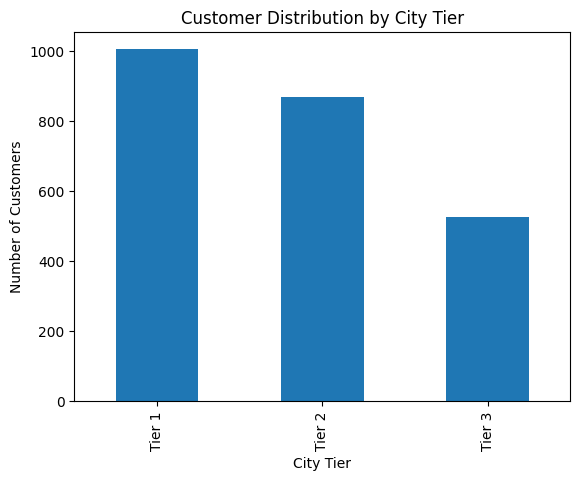

In [80]:
# City tier visualization

customers['city_tier'].value_counts().plot(kind='bar')

plt.title("Customer Distribution by City Tier")
plt.xlabel("City Tier")
plt.ylabel("Number of Customers")

plt.show()

- 3.2 Order & Monetary Behaviour

# Order & Revenue Analysis

In [81]:
# Total revenue

total_revenue = orders['gross_amount'].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 7445680.13


In [82]:
# Average order value

average_order_value = orders['gross_amount'].mean()

print("Average Order Value:", average_order_value)

Average Order Value: 743.8985043460885


In [83]:
# Top selling categories

orders['category'].value_counts()

category
Skin Care    2700
Hair Care    2191
Makeup       1507
Baby Care    1438
Wellness     1096
Fragrance    1077
Name: count, dtype: int64

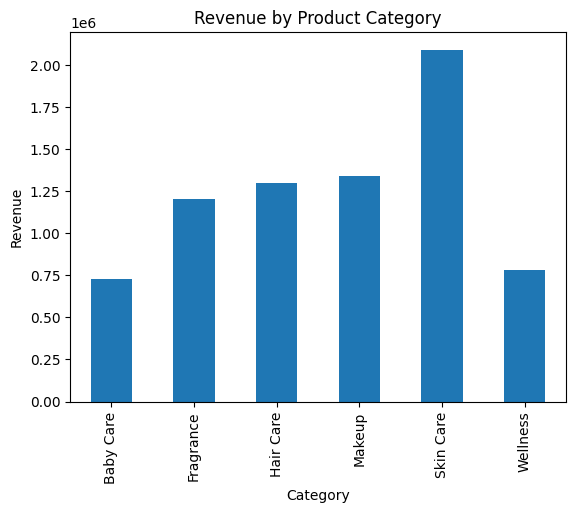

In [84]:
# Revenue by category

category_revenue = orders.groupby('category')['gross_amount'].sum()

category_revenue.plot(kind='bar')

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.show()

- 3.3 Monthly Order & Revenue Trends (pre-snapshot)

# Monthly Order Trend Analysis

In [85]:
# Extract month from pre-snapshot order date for churn-relevant evidence

orders_pre_snapshot_copy = orders_pre_snapshot.copy()
orders_pre_snapshot_copy['order_month'] = orders_pre_snapshot_copy['order_date'].dt.to_period('M')

monthly_orders = orders_pre_snapshot_copy.groupby('order_month').size()
monthly_orders

order_month
2024-01     19
2024-02     44
2024-03    109
2024-04    132
2024-05    162
2024-06    203
2024-07    229
2024-08    263
2024-09    297
2024-10    372
2024-11    398
2024-12    456
2025-01    503
2025-02    507
2025-03    578
2025-04    594
2025-05    631
2025-06    527
2025-07    672
2025-08    669
2025-09    772
Freq: M, dtype: int64

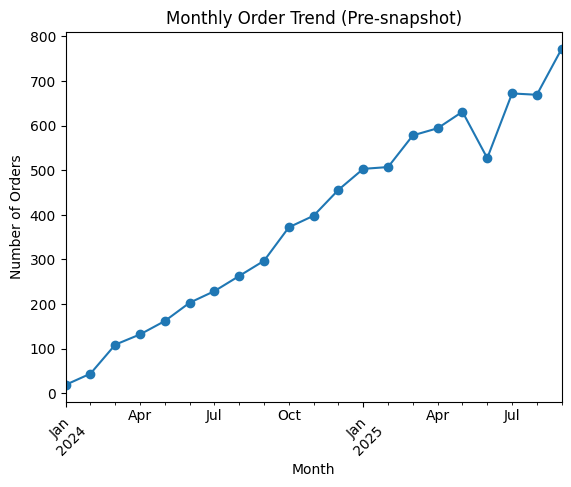

In [86]:
# Monthly order trend visualization (pre-snapshot only)
monthly_orders.plot(kind='line', marker='o')

plt.title('Monthly Order Trend (Pre-snapshot)')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.show()

order_month
2024-01     11405.15
2024-02     35149.17
2024-03     87411.08
2024-04     92043.86
2024-05    128909.38
2024-06    141201.04
2024-07    183872.28
2024-08    191534.88
2024-09    225810.29
2024-10    281448.94
2024-11    307665.55
2024-12    345847.17
2025-01    360382.26
2025-02    381837.57
2025-03    471376.69
2025-04    449981.25
2025-05    464104.53
2025-06    397457.46
2025-07    497103.15
2025-08    511550.72
2025-09    553081.33
2025-10    712687.22
2025-11    613819.16
Freq: M, Name: gross_amount, dtype: float64


<Axes: title={'center': 'Monthly Revenue Trend'}, xlabel='order_month'>

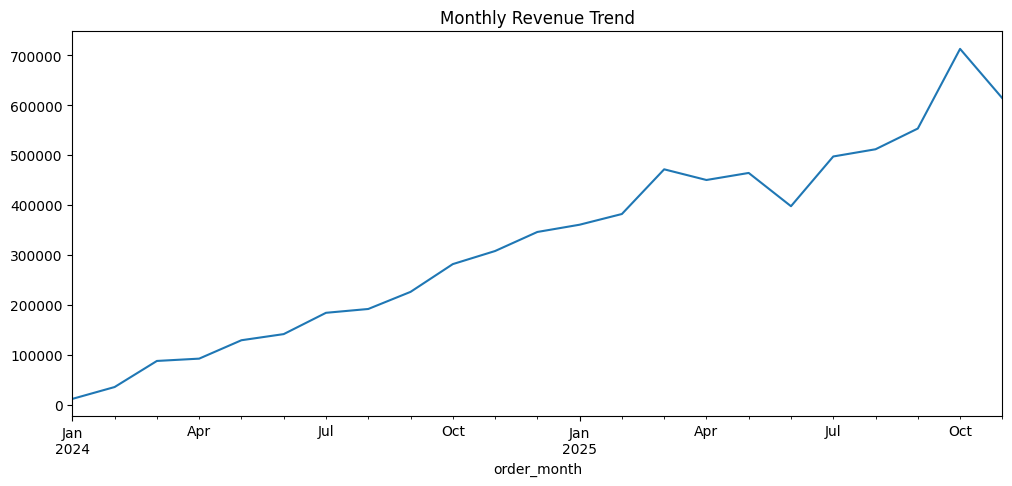

In [87]:
# Monthly revenue trend

orders['order_date'] = pd.to_datetime(
    orders['order_date']
)

orders['order_month'] = orders['order_date'].dt.to_period('M')

monthly_revenue = orders.groupby(
    'order_month'
)['gross_amount'].sum()

print(monthly_revenue)

monthly_revenue.plot(
    figsize=(12,5),
    title="Monthly Revenue Trend"
)

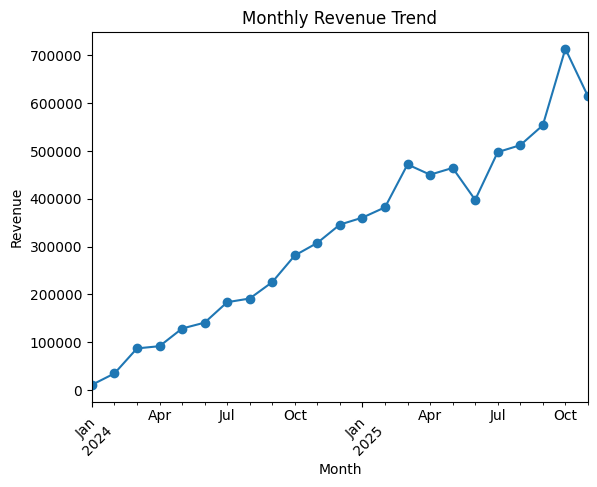

In [88]:
# Monthly revenue visualization

monthly_revenue.plot(kind='line', marker='o')

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

- 3.4 Customer Signup Trend

# Customer Signup Trend

In [89]:
# Monthly signup trend

customers['signup_month'] = customers['signup_date'].dt.to_period('M')

signup_trend = customers.groupby('signup_month').size()

signup_trend

signup_month
2024-01    116
2024-02    106
2024-03    120
2024-04    124
2024-05    117
2024-06    125
2024-07    121
2024-08    114
2024-09    111
2024-10    133
2024-11    127
2024-12    116
2025-01    127
2025-02    104
2025-03    112
2025-04    110
2025-05    114
2025-06    100
2025-07    116
2025-08    120
2025-09     67
Freq: M, dtype: int64

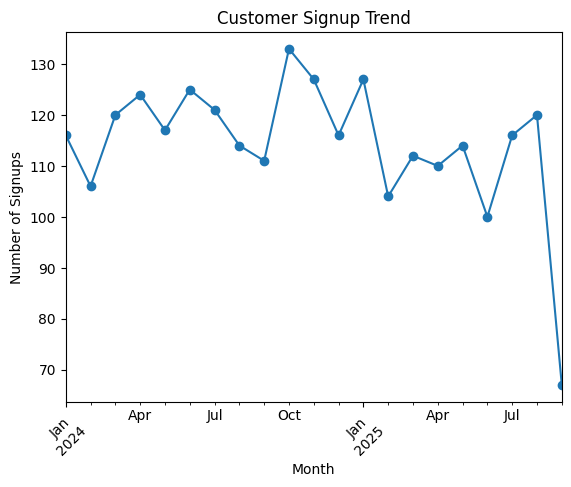

In [90]:
# Signup trend visualization

signup_trend.plot(kind='line', marker='o')

plt.title("Customer Signup Trend")
plt.xlabel("Month")
plt.ylabel("Number of Signups")

plt.xticks(rotation=45)

plt.show()

- 3.5 Churn Distribution

# Churn Analysis

In [91]:
# Churn distribution

churn_labels.columns

Index(['customer_id', 'snapshot_date', 'churn_next_60d', 'split'], dtype='str')

In [92]:
# Churn distribution

churn_labels['churn_next_60d'].value_counts()

churn_next_60d
0    1273
1    1127
Name: count, dtype: int64

In [93]:
# Churn percentage

churn_percentage = churn_labels['churn_next_60d'].value_counts(normalize=True) * 100

print(churn_percentage)

churn_next_60d
0    53.041667
1    46.958333
Name: proportion, dtype: float64


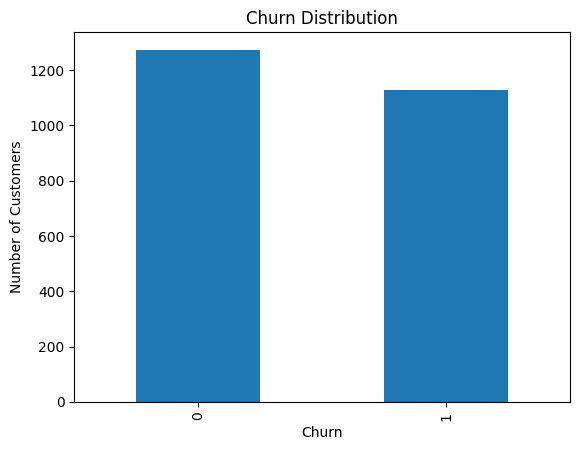

In [94]:
# Churn visualization

churn_labels['churn_next_60d'].value_counts().plot(kind='bar')

plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

# 4. Churn-Risk Hypotheses
Each hypothesis below is supported by a chart/table plus a short interpretation. Statistical tests are at the end of this section.

- H1. Customers with more support tickets churn at higher rates

# Support Experience & Churn Analysis

In [22]:
support_churn = support_tickets.merge(
    churn_labels,
    on="customer_id",
    how="left"
)

support_churn.head()

,ticket_id,customer_id,ticket_date,issue_type,support_channel,resolution_hours,sentiment_score,reopened,snapshot_date,churn_next_60d,split
0,TKT000001,CUST00001,2024-10-28,damaged_item,chat,3.9,-0.16,0,2025-09-30,1,train
1,TKT000002,CUST00001,2025-02-03,payment_issue,chat,4.8,0.44,0,2025-09-30,1,train
2,TKT000003,CUST00002,2025-08-30,late_delivery,chat,1.0,0.00,0,2025-09-30,0,train
3,TKT000004,CUST00005,2025-05-02,late_delivery,call,37.7,-1.00,0,2025-09-30,0,train
4,TKT000005,CUST00006,2025-08-13,general_query,call,23.1,-0.68,1,2025-09-30,0,validation


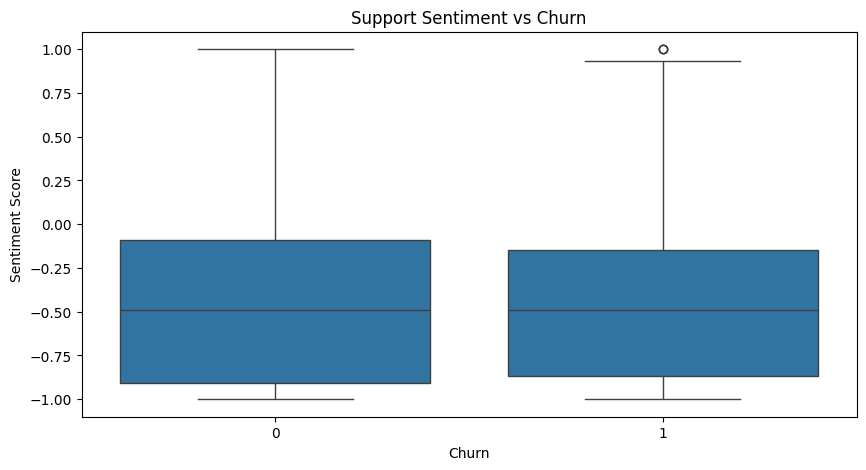

In [23]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=support_churn,
    x="churn_next_60d",
    y="sentiment_score"
)

plt.title("Support Sentiment vs Churn")

plt.xlabel("Churn")
plt.ylabel("Sentiment Score")

plt.show()

- H2. Reopened tickets predict churn


In [24]:
reopened_churn = (
    support_churn
    .groupby("reopened")["churn_next_60d"]
    .mean()
)

reopened_churn

reopened
0    0.438963
1    0.417647
Name: churn_next_60d, dtype: float64

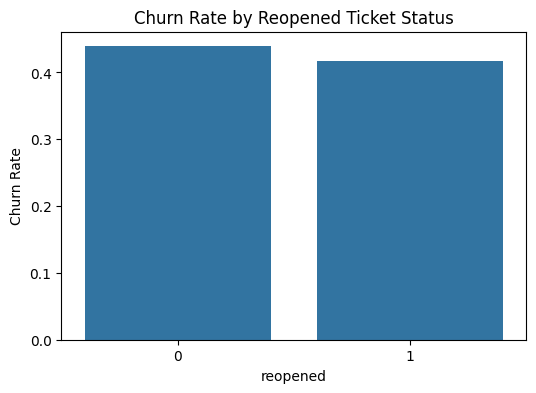

In [25]:
plt.figure(figsize=(6,4))

sns.barplot(
    x=reopened_churn.index,
    y=reopened_churn.values
)

plt.title("Churn Rate by Reopened Ticket Status")

plt.ylabel("Churn Rate")

plt.show()

- H3. Negative-sentiment tickets predict churn

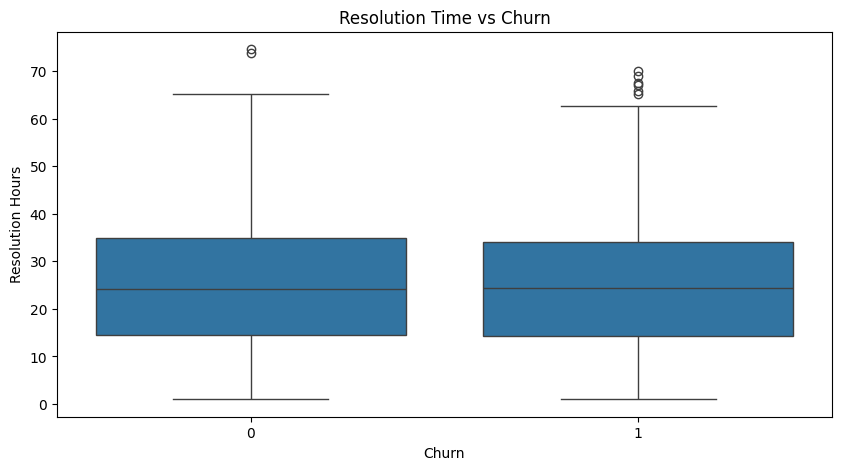

In [26]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=support_churn,
    x="churn_next_60d",
    y="resolution_hours"
)

plt.title("Resolution Time vs Churn")

plt.xlabel("Churn")
plt.ylabel("Resolution Hours")

plt.show()

- H4. Low digital engagement (sessions, pages, recency) predicts churn

# Digital Engagement & Churn Analysis

In [27]:
web_churn = web_events.merge(
    churn_labels,
    on="customer_id",
    how="left"
)

web_churn.head()

,customer_id,snapshot_date_x,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,snapshot_date_y,churn_next_60d,split
0,CUST00001,2025-09-30,1,4,0,0,0,2,0,20,2025-09-30,1,train
1,CUST00002,2025-09-30,8,31,4,2,3,0,0,0,2025-09-30,0,train
2,CUST00003,2025-09-30,1,3,0,0,0,0,0,26,2025-09-30,1,train
3,CUST00004,2025-09-30,1,6,0,0,0,0,0,14,2025-09-30,1,train
4,CUST00005,2025-09-30,18,95,4,1,1,3,1,9,2025-09-30,0,train


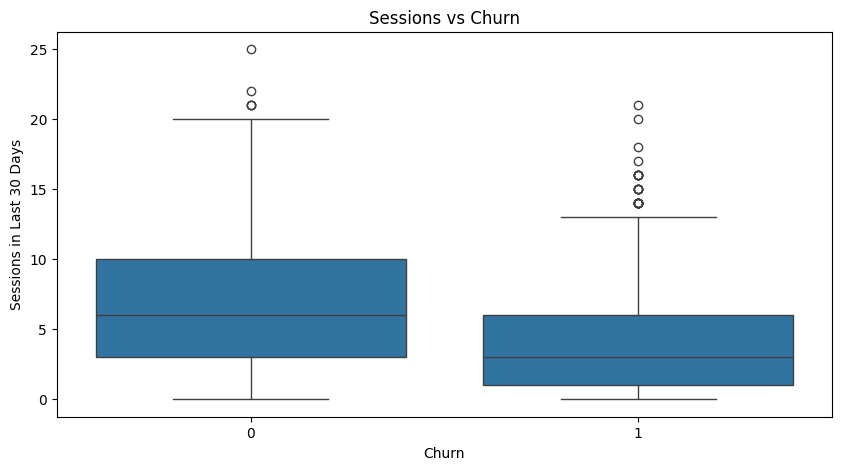

In [28]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=web_churn,
    x="churn_next_60d",
    y="sessions_30d"
)

plt.title("Sessions vs Churn")

plt.xlabel("Churn")
plt.ylabel("Sessions in Last 30 Days")

plt.show()

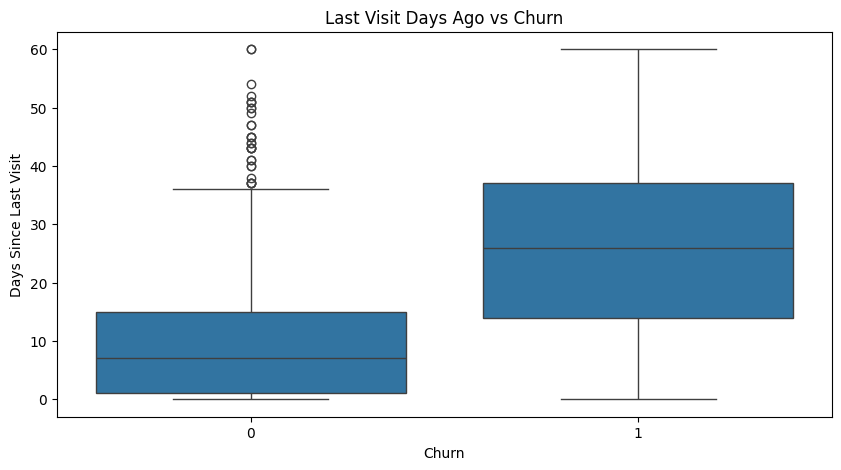

In [29]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=web_churn,
    x="churn_next_60d",
    y="last_visit_days_ago"
)

plt.title("Last Visit Days Ago vs Churn")

plt.xlabel("Churn")
plt.ylabel("Days Since Last Visit")

plt.show()

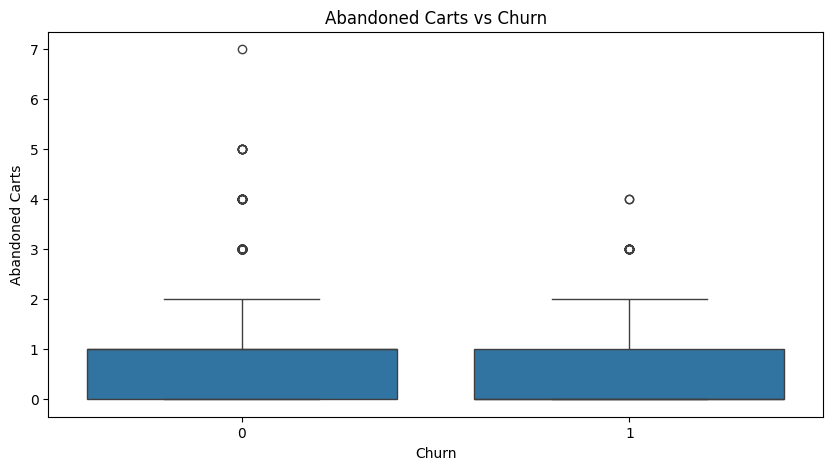

In [30]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=web_churn,
    x="churn_next_60d",
    y="abandoned_carts_30d"
)

plt.title("Abandoned Carts vs Churn")

plt.xlabel("Churn")
plt.ylabel("Abandoned Carts")

plt.show()

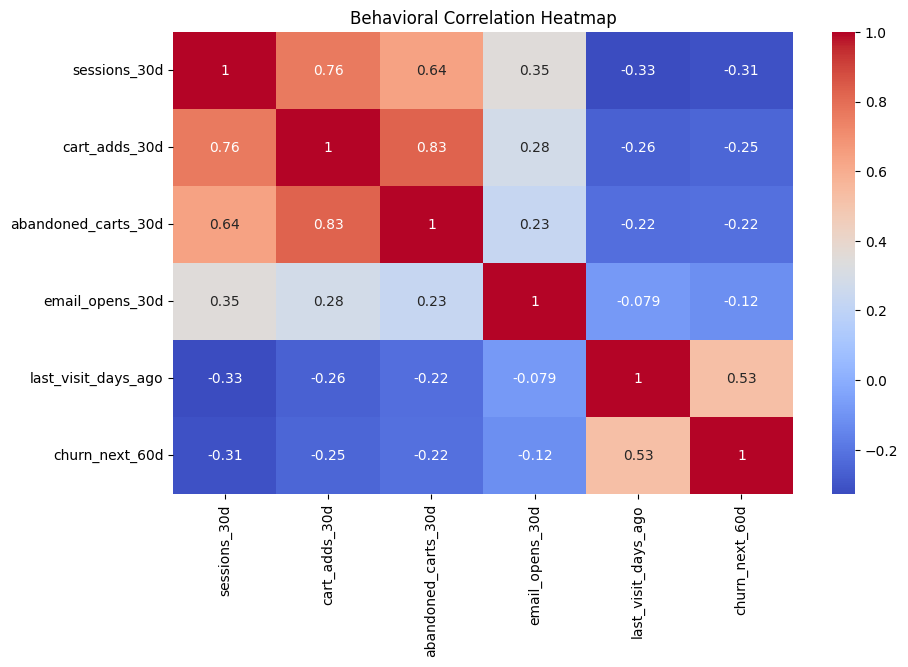

In [31]:
corr_cols = [
    'sessions_30d',
    'cart_adds_30d',
    'abandoned_carts_30d',
    'email_opens_30d',
    'last_visit_days_ago',
    'churn_next_60d'
]

plt.figure(figsize=(10,6))

sns.heatmap(
    web_churn[corr_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Behavioral Correlation Heatmap")

plt.show()

- H5. City-tier influences churn

# Customer Distribution Analysis

In [95]:
# Merge customer and churn data

customer_churn = customers.merge(
    churn_labels,
    on='customer_id',
    how='left'
)

customer_churn.head()


,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent,signup_month,snapshot_date,churn_next_60d,split
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes,2024-04,2025-09-30,1,train
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes,2025-06,2025-09-30,0,train
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes,2025-03,2025-09-30,1,train
3,CUST00004,2025-04-15,Tier 3,25-34,Google Search,NaN,Fragrance,Normal,No,2025-04,2025-09-30,1,train
4,CUST00005,2024-08-21,Tier 3,35-44,Organic,Gold,Hair Care,Combination,Yes,2024-08,2025-09-30,0,train


In [96]:
# Check merged dataset shape

customer_churn.shape

(2400, 13)

In [97]:
# Churn by city tier

customer_churn.groupby('city_tier')['churn_next_60d'].mean()

city_tier
Tier 1    0.473632
Tier 2    0.477011
Tier 3    0.449524
Name: churn_next_60d, dtype: float64

- H6. Acquisition channel influences churn

# Churn Analysis by Acquisition Channel

In [98]:
# Churn rate by acquisition channel

customer_churn.groupby('acquisition_channel')['churn_next_60d'].mean().sort_values(ascending=False)

acquisition_channel
Google Search    0.504292
Instagram        0.499033
Marketplace      0.491228
Influencer       0.476190
Referral         0.421717
Organic          0.398204
Name: churn_next_60d, dtype: float64

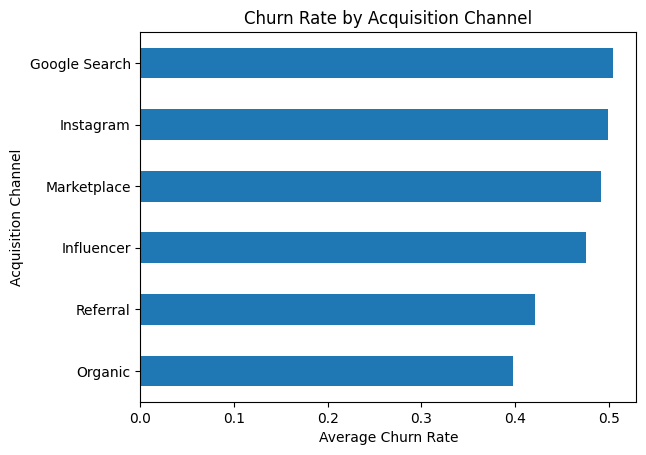

In [99]:
# Visualization

customer_churn.groupby('acquisition_channel')['churn_next_60d'].mean().sort_values().plot(kind='barh')

plt.title("Churn Rate by Acquisition Channel")
plt.xlabel("Average Churn Rate")
plt.ylabel("Acquisition Channel")

plt.show()

- H7. Age group influences churn
 

# Churn Analysis by Age Group


In [100]:
# Churn rate by age group

customer_churn.groupby('age_group')['churn_next_60d'].mean().sort_values(ascending=False)

age_group
35-44    0.483146
25-34    0.471770
45+      0.463602
18-24    0.455357
Name: churn_next_60d, dtype: float64

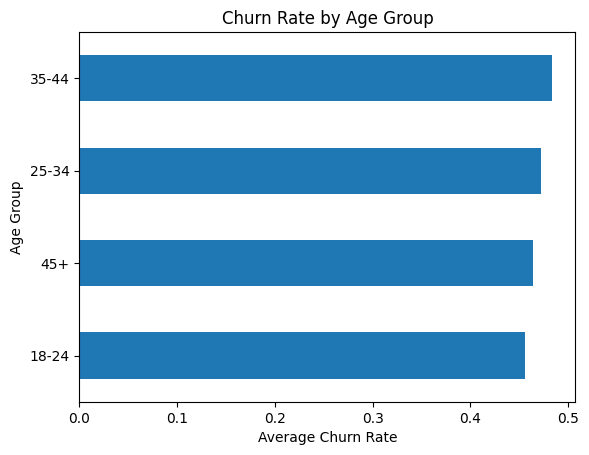

In [101]:
# Visualization

customer_churn.groupby('age_group')['churn_next_60d'].mean().sort_values().plot(kind='barh')

plt.title("Churn Rate by Age Group")
plt.xlabel("Average Churn Rate")
plt.ylabel("Age Group")

plt.show()

- H8. Preferred product category influences churn


# Churn Analysis by Preferred Category


In [102]:
# Churn by preferred category

customer_churn.groupby('preferred_category')['churn_next_60d'].mean().sort_values(ascending=False)

preferred_category
Baby Care    0.507205
Wellness     0.482072
Skin Care    0.471956
Makeup       0.453988
Fragrance    0.453782
Hair Care    0.451677
Name: churn_next_60d, dtype: float64

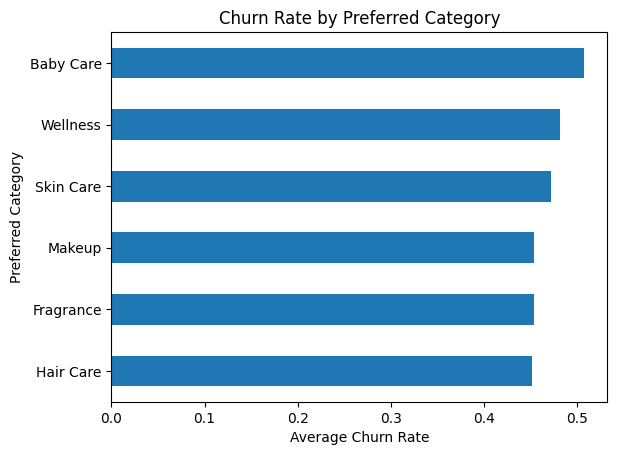

In [103]:
# Visualization

customer_churn.groupby('preferred_category')['churn_next_60d'].mean().sort_values().plot(kind='barh')

plt.title("Churn Rate by Preferred Category")
plt.xlabel("Average Churn Rate")
plt.ylabel("Preferred Category")

plt.show()

- 4.x Statistical significance (chi-square)


In [104]:
from scipy.stats import chi2_contingency
for col in ["city_tier","acquisition_channel","age_group","preferred_category"]:
    ct = pd.crosstab(customer_churn[col], customer_churn["churn_next_60d"])
    chi2, p, *_ = chi2_contingency(ct)
    print(f"{col}: chi2={chi2:.1f}, p={p:.4f}")

city_tier: chi2=1.1, p=0.5749
acquisition_channel: chi2=15.4, p=0.0087
age_group: chi2=0.9, p=0.8237
preferred_category: chi2=3.4, p=0.6454


- 4.y Customer-level feature aggregation for modelling hand-off


In [105]:
support_features = support_tickets.groupby("customer_id").agg(
    n_tickets=("ticket_id","count"),
    avg_resolution_hours=("resolution_hours","mean"),
    any_reopened=("reopened","max"),
    avg_sentiment=("sentiment_score","mean"),
).reset_index().merge(churn_labels, on="customer_id", how="left")

for col in ["n_tickets","avg_resolution_hours","any_reopened","avg_sentiment"]:
    print(col, "→ churn corr:", support_features[col].corr(support_features["churn_next_60d"]).round(3))


n_tickets → churn corr: -0.12
avg_resolution_hours → churn corr: -0.012
any_reopened → churn corr: -0.046
avg_sentiment → churn corr: -0.014


In [106]:
customer_churn.groupby(
    'acquisition_channel'
)['churn_next_60d'].mean().sort_values(ascending=False)

acquisition_channel
Google Search    0.504292
Instagram        0.499033
Marketplace      0.491228
Influencer       0.476190
Referral         0.421717
Organic          0.398204
Name: churn_next_60d, dtype: float64

# 5. Cleaned Dataset Export
---
Removes duplicate-like orders, caps p99 outliers, and writes orders_clean.csv for Parts 2–4.

In [107]:
orders_clean = orders_pre_snapshot[~orders_pre_snapshot["order_id"].str.contains("_DUP", na=False)].copy()
print("Rows dropped:", len(orders_pre_snapshot) - len(orders_clean))
print("Revenue removed:", orders_pre_snapshot.loc[orders_pre_snapshot.order_id.str.contains("_DUP", na=False), "gross_amount"].sum())

Rows dropped: 9
Revenue removed: 6093.360000000001


In [108]:
p99 = orders_clean["gross_amount"].quantile(0.99)
orders_clean["gross_amount_capped"] = orders_clean["gross_amount"].clip(upper=p99)
print(f"Capped at p99 = {p99:.0f}")

Capped at p99 = 2343


In [109]:
# EDA Summary Table

summary_table = pd.DataFrame({

    "Metric": [

        "Total Customers",
        "Total Orders",
        "Overall Churn Rate",
        "Average Order Value",
        "Duplicate-like Orders",
        "Post-Snapshot Orders"

    ],

    "Value": [

        customers.shape[0],
        orders.shape[0],
        churn_labels["churn_next_60d"].mean(),
        orders["gross_amount"].mean(),
        dup_orders.shape[0],
        post_snapshot_orders.shape[0]

    ]

})

summary_table


,Metric,Value
0,Total Customers,2400.000000
1,Total Orders,10009.000000
2,Overall Churn Rate,0.469583
3,Average Order Value,743.898504
4,Duplicate-like Orders,12.000000
5,Post-Snapshot Orders,1872.000000


In [110]:
# Export Cleaned Dataset

orders_clean.to_csv(
    "orders_clean.csv",
    index=False
)

print("orders_clean.csv exported successfully")


orders_clean.csv exported successfully


# 6. Sanity Summary


In [111]:
print("Post-snapshot order rows:", post_snapshot_orders.shape[0])


Post-snapshot order rows: 1872


In [112]:
print("Duplicate-like order rows:", dup_orders.shape[0])


Duplicate-like order rows: 12


In [113]:
print("Revenue impact of duplicate-like rows:")

dup_orders["gross_amount"].sum()

Revenue impact of duplicate-like rows:


np.float64(7928.05)